<a href="https://colab.research.google.com/github/fahradnamazov-ops/RL_k_armed_bandit/blob/main/session_01_k_armed_bandit_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/shared_assets/logo.png)


**Developers:** Domonkos Nagy, Balázs Nagy, Zoltán Barta  
**Date:** 2026-02-17  
**Version:** 2025-26/2

[<img src="https://colab.research.google.com/assets/colab-badge.svg">](https://colab.research.google.com/github/BartaZoltan/deep-reinforcement-learning-course/blob/main/notebooks/sessions/session_01_k_armed_bandit/session_01_k_armed_bandit_student.ipynb)

# Practice 1: K-armed Bandit

## Summary

This notebook introduces the **k-armed bandit** setting and the exploration-exploitation tradeoff in reinforcement learning.

Content outline:
- k-armed bandit problem formulation and evaluation setup,
- strategy interface and environment construction,
- epsilon-greedy action selection,
- upper-confidence-bound (UCB) action selection,
- gradient bandit methods,
- comparative experiments and result interpretation.
- non-stationarity in bandit problem


## Introduction

Consider the following learning problem. You are faced repeatedly with a choice among
$k$ different options, or actions. After each choice, you receive a numerical reward
from a stationary probability distribution that depends on the action you selected. Your
objective is to maximize the expected total reward over some time period, for example,
over 1000 action selections, or time steps.

This is called the $k$-armed bandit problem. You can visualize this problem as having to
choose between $k$ slot machines (also known as one-armed bandits) at each time step,
each of which has a different probability distribution for rewards - that is where the name comes from.

<img src="https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/session_01_k_armed_bandit/assets/k_armed_bandit.png" width="500"/>

The $k$-armed bandit problem illustrates an important problem in reinforcement
learning: **exploration vs. exploitation**. At each time step $t$, the agent has to make a decision:
take the action with the highest expected reward according to its current knowledge of the environment,
or choose a different action to get a better estimation of the value of that action. The former is called an
*exploitation* step, because it exploits the current knowledge of the agent in order to obtain a high reward.
The latter is called an *exploration* step, since it involves trying out an action in order to have a better
estimation of its value, thereby exploring the environment.

This notebook introduces a few common strategies to tackle this problem and puts them to the test by simulating
multiple test runs, and comparing the results.

This notebook follows Chapter 2 of Sutton & Barto {cite}`sutton2018`.


In [1]:
import numpy as np
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
from tqdm.notebook import trange
import seaborn as sns
import time
# Initialize bandit and strategy
import os
from pathlib import Path
from PIL import Image
from IPython.display import Image as IPyImage, display
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
except Exception:
    pass


### Why the seed setup matters

Bandit methods are stochastic in two ways: the environment generates random rewards and the policy often explores randomly.
Setting a fixed seed makes experiments reproducible and comparable across strategy variants.

This follows the testbed philosophy in Chapter 2: compare methods under controlled conditions and average over many runs {cite}`sutton2018`.


## Strategy setup

The `Strategy` base class is used to implement startegies for action selection. An action is selected by the `act` method, and then the `update` method is used
to update the inner state after receiving a reward for the selected action. After an episode (a "run" consisting of $n$ steps, 1000 for example) is over, the `reset` method is called to reset the inner state of the class. The `name` propery is used get a name for the strategy in a visual representation.

In [2]:
# DO NOT MODIFY THIS CELL

class Strategy(ABC):

    def __init__(self, k):
        self.k = k  # Number of actions

        self.rewards_history = {i: [] for i in range(self.k)}  # Store observed rewards per action

    @property
    @abstractmethod
    def name():
        pass

    @abstractmethod
    def act(self):
        pass

    @abstractmethod
    def update(self, action, reward):
        self.rewards_history[action].append(reward)  # Update rewards history
        pass

    @abstractmethod
    def reset(self):
        self.rewards_history = {i: [] for i in range(self.k)}  # Reset reward history
        pass

    def plot_estimated_distributions(self):
        """
        Plots the estimated reward distributions for each action
        based on the rewards observed during training.
        """
        plt.figure(figsize=(12, 5))
        for action, rewards in self.rewards_history.items():
            if rewards:
                sns.kdeplot(rewards, label=f"Action {action+1}", fill=True, alpha=0.5)

        plt.xlabel("Estimated Reward")
        plt.ylabel("Density")
        plt.title(f"Estimated Reward Distributions - {self.name}")
        plt.legend()
        plt.show()

Numpy's `np.argmax` will choose the smallest index in case there are multiple
maximal values. This function breaks these ties randomly instead, which is
desirable in many cases.

In [3]:
# DO NOT MODIFY THIS CELL

# Argmax function that breaks ties randomly
def argmax(arr):
    arr_max = np.max(arr)
    return np.random.choice(np.where(arr == arr_max)[0])

## Environment Setup

We test our strategies by trying them out in multiple runs, and then averaging out the received reward at each time step. After that, we plot the results to
compare the strategies.

### Task 1


**Build the stationary k-armed bandit environment** (5-10 min)

Your first implementation task is to complete the `KArmedBandit` class so strategies can interact with a valid stochastic environment.

What you should implement:
- Store the number of actions (`K`) and the initialization distribution parameters (`mean`, `std_dev`).
- Sample one true action value for each arm (`q*(a)`) from the initialization distribution.
- Return stochastic rewards for a selected action, centered around that action's true value.
- Return the index of the currently optimal action.
- Reinitialize the environment when `reset()` is called.

How it should work conceptually:
- The bandit is **stationary**: true action values do not drift during a run.
- Rewards are noisy samples, so repeated pulls of the same arm can differ.
- A new run should start with a new random draw of true action values.

Quick sanity checks before moving on:
- `plot_bandit_distributions(...)` produces distinct arm distributions.
- The marker for true action values is consistent with the sampled rewards.
- `get_optimal_action()` matches the arm with the highest current true value.

In [5]:
class KArmedBandit:
    def __init__(self, K, mean=0, std_dev=1):
        """
        Initializes the K-armed bandit with normally distributed action values.

        Parameters:
        - K (int): Number of arms.
        - mean (float): Mean of the normal distribution for optimal action values.
        - std_dev (float): Standard deviation for the optimal action values.
        """
        self.K = K
        self.mean = mean
        self.std_dev = std_dev
        self.actions_means = np.random.normal(self.mean, self.std_dev, self.K)

    def get_reward(self, action):
        """
        Returns a stochastic reward from a normal distribution centered at the true action value.

        Parameters:
        - action (int): The index of the chosen action.

        Returns:
        - reward (float): The observed reward for the selected action.
        """
        return np.random.normal(loc=self.actions_means[action], scale=1.0)

    def get_optimal_action(self):
        """
        Returns the index of the optimal action (the arm with the highest expected reward).
        """
        return np.argmax(self.actions_means)

    def reset(self):
        """
        Resets the bandit by re-generating the optimal action values.
        """
        self.actions_means = np.random.normal(self.mean, self.std_dev, self.K)


In [6]:
def plot_bandit_distributions(bandit, num_samples=10000):
    """
    Plots the reward distributions for all K actions in a K-armed bandit using a violin plot.

    Parameters:
    - bandit (KArmedBandit): An instance of the KArmedBandit class.
    - num_samples (int): Number of reward samples to generate for each action.
    """
    K = bandit.K  # Number of actions
    rewards = {action: [bandit.get_reward(action) for _ in range(num_samples)] for action in range(K)}

    # Convert to data format suitable for seaborn
    reward_data = []
    action_labels = []

    for action, reward_list in rewards.items():
        reward_data.extend(reward_list)
        action_labels.extend([action + 1] * num_samples)  # Convert 0-indexed to 1-indexed for display

    # Create violin plot
    plt.figure(figsize=(12, 5))
    sns.violinplot(x=action_labels, y=reward_data, inner=None, color="lightblue", linewidth=1.5)

    # Add scatter points for true action values
    plt.scatter(range(0, K ), bandit.actions_means, color='blue', s=50)

    # Formatting
    plt.axhline(0, linestyle='dotted', color='black', linewidth=1)  # Dashed line at 0
    plt.xlabel("Actions")
    plt.ylabel("Expected Reward")
    plt.title("Action Reward Distributions in K-Armed Bandit")
    plt.show()

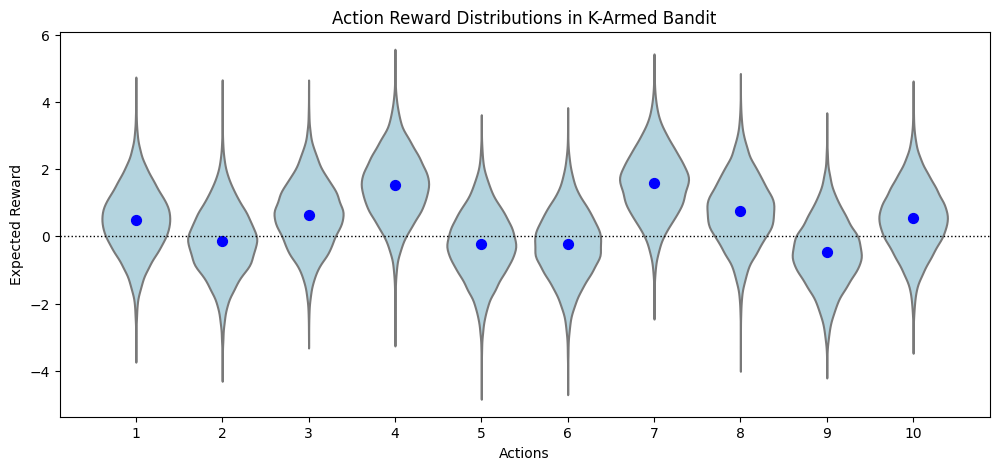

In [7]:
# Create a 10-armed bandit
bandit = KArmedBandit(K=10)

# Plot the full action reward distributions
plot_bandit_distributions(bandit)

### Task 2

**Main simulation loop** (5-10 min)

This block executes the evaluation protocol for all strategies.

- Outer loop (`i, strategy`): iterate over strategies to compare.
- Run loop (`run`): repeat independent trials for statistical reliability.
- `KArmedBandit(...)`: create a fresh environment for each run.
- `best_action = bandit.get_optimal_action()`: store the true optimal arm for the current run.
- `strategy.reset()`: ensure each run starts with a clean strategy state.

At each time step:
- select action:
- sample reward:
- update strategy
- log reward
- log optimal-action hit

After the loop, results are averaged across runs to obtain:
- mean reward per step,
- optimal-action selection rate per step.


In [8]:
# DO NOT MODIFY THIS CELL
def simulate(strategies, K, bandit_mean = 0, bandit_std = 1,runs=2000, n_steps=1000):
    """
    Simulates the K-armed bandit problem with different strategies.

    Parameters:
    - strategies (list): A list of strategies to evaluate.
    - K (int): Number of arms.
    - runs (int): Number of independent runs.
    - n_steps (int): Number of time steps per run.

    Returns:
    - mean_rewards (np.array): Average rewards per time step for each strategy.
    - mean_best_action_choices (np.array): Average probability of selecting the best action.
    """
    rewards = np.zeros((len(strategies), runs, n_steps))
    best_action_choices = np.zeros(rewards.shape)

    for i, strategy in enumerate(strategies):
        for run in trange(runs, desc=f"Simulating {strategy.name}", leave=False):
            # Create a fresh environment for each run
            bandit = KArmedBandit(K, mean=bandit_mean, std_dev=bandit_std)
            best_action = bandit.get_optimal_action()

            # Start with a clean strategy state
            strategy.reset()

            for t in range(n_steps):
                action = strategy.act()
                reward = bandit.get_reward(action)
                strategy.update(action, reward)

                # Log reward and optimal-action hit
                rewards[i, run, t] = reward
                best_action_choices[i, run, t] = 1 if action == best_action else 0

    # Compute mean rewards and best action selection frequency
    mean_rewards = rewards.mean(axis=1)
    mean_best_action_choices = best_action_choices.mean(axis=1)

    return mean_rewards, mean_best_action_choices


To examine the results a plot function is defined.

In [9]:
# DO NOT MODIFY THIS CELL

def plotResults(strategies, rewards, best_action_choices):
  fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

  for strategy, reward in zip(strategies, rewards):
      ax1.plot(reward, label=f"{strategy.name}", zorder=2)
  ax1.set_xlabel('Steps')
  ax1.set_ylabel('Average reward')
  ax1.grid(alpha=0.8, linestyle=':', zorder=0)
  ax1.set_title('Average reward of strategies')
  ax1.legend()

  for strategy, choices in zip(strategies, best_action_choices):
      ax2.plot(choices, label=f"{strategy.name}")
  ax2.set_xlabel('Steps')
  ax2.set_ylabel('% Optimal action')
  ax2.grid(alpha=0.8, linestyle=':', zorder=0)
  ax2.set_title('% Optimal action choices of strategies')
  ax2.legend()

  plt.show()

## $\varepsilon$-greedy Action Selection

With this method, the agent will select a random action with an $\varepsilon$ probability ($0 \le \varepsilon \le 1$), and act greedily (select the best action according to its knowledge) otherwise. The action values are calculated using the *sample-averages* method: the value of an action is the average of all the rewards received after taking that action.



<img src="https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/sessions/session_01_k_armed_bandit/assets/epsilon_greedy.png" width="700"/>

*Pseudocode adapted from Sutton & Barto {cite}`sutton2018` (p. 32).*




### Task 3

**Implement Epsilon-Greedy Strategy** (10 min)

Complete the `EpsilonGreedy` class so it can be evaluated with `simulate(...)`.

What to implement:
- `__init__(...)`
  - store `epsilon`, `initial`, optional `step_size`
  - initialize action-value estimates and action counts
- `act()`
  - with probability `epsilon`, choose a random action
  - otherwise choose greedy action using current estimates
- `update(action, reward)`
  - increment selected action count
  - update only the selected action estimate
  - use sample-average update if `step_size is None`, else constant step-size update
- `reset()`
  - reset estimates and counts for a new run

Expected behavior:
- `epsilon=0`: pure greedy behavior
- `epsilon>0`: occasional exploration with otherwise greedy action selection
- with repeated updates, estimates should move toward observed rewards

Quick checks:
- selected action index is always valid
- only selected action value changes on each update
- reset restores initial state


In [10]:


class EpsilonGreedy(Strategy):
    def __init__(self, k, epsilon=0, initial=0,step_size=None, name_suffix=""):
        """
        Initializes the epsilon-greedy strategy.

        Parameters:
        - k (int): Number of actions (arms).
        - epsilon (float): Probability of exploring a random action.
        - initial (float): Initial value for action-value estimates.
        - name_suffix (str): Suffix to append to the strategy name.
        """
        super().__init__(k)  # Initialize parent Strategy class
        self.epsilon = epsilon
        self.initial = initial
        self.step_size = step_size
        self.name_suffix = name_suffix
        self.q_estimations = np.full(self.k, self.initial, dtype=float)
        self.action_counts = np.zeros(self.k, dtype=int)

    @property
    def name(self):
        """
        Returns a formatted string representing the strategy name.
        """
        name_str = "Greedy" if self.epsilon == 0 else f"$\\varepsilon$-greedy, $\\varepsilon = {self.epsilon}$"
        if self.initial != 0:
            name_str += f", init: {self.initial}"  # Include initial value if non-zero
        if self.name_suffix:
            name_str += f", {self.name_suffix}"  # Include name suffix if provided
        return name_str

    def act(self):
        """
        Selects an action based on the epsilon-greedy policy.

        Returns:
        - (int) Index of the selected action.
        """
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.k)
        else:
            return argmax(self.q_estimations)

    def update(self, action, reward):
        """
        Updates the action-value estimate using sample averaging.

        Parameters:
        - action (int): Index of the chosen action.
        - reward (float): Reward received from the environment.
        """
        super().update(action, reward)  # Call parent class update method if needed
        self.action_counts[action] += 1
        alpha = 1.0 / self.action_counts[action] if self.step_size is None else self.step_size
        self.q_estimations[action] += alpha * (reward - self.q_estimations[action])

    def reset(self):
        """
        Resets the internal state of the strategy for a new experiment.
        """
        super().reset()  # Call parent class reset method if needed
        self.q_estimations = np.full(self.k, self.initial, dtype=float)
        self.action_counts = np.zeros(self.k, dtype=int)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

def plot_and_save(strategy, step,save_path = "assets/bandit_training.png"):
    """
    Creates and updates the figure, then saves it to disk.

    Parameters:
    - strategy (EpsilonGreedy): The current strategy with reward history.
    - step (int): Current training step.
    """
    K = strategy.k

    # Create new figure inside the function
    fig, ax = plt.subplots(figsize=(12, 5))

    # Prepare data
    reward_data = []
    action_labels = []

    for action, reward_list in strategy.rewards_history.items():
        reward_data.extend(reward_list)
        action_labels.extend([action+1] * len(reward_list))

    # Create violin plot
    sns.violinplot(x=action_labels, y=reward_data, inner=None, density_norm="width", color="lightcoral", linewidth=1.5, ax=ax)

    # Scatter plot for estimated means
    ax.scatter(range(K), strategy.q_estimations, color='red', s=50, zorder=3, label="Estimated Means")

    ax.axhline(0, linestyle='dotted', color='black', linewidth=1)
    ax.set_xlabel("Actions")
    ax.set_ylabel("Estimated Reward")
    ax.set_title(f"Training Step: {step} - Estimated Reward Distributions")
    ax.legend(["Estimated Means"])

    # Save the figure to the same file (overwrite each time)
    fig.savefig(save_path, format="png", dpi=150)
    plt.close(fig)  # Close figure to free memory

Visualize, how the $\varepsilon$-greedy Action Selection updates it's estimations of the reward distributions of the K-Armed bandit problem.

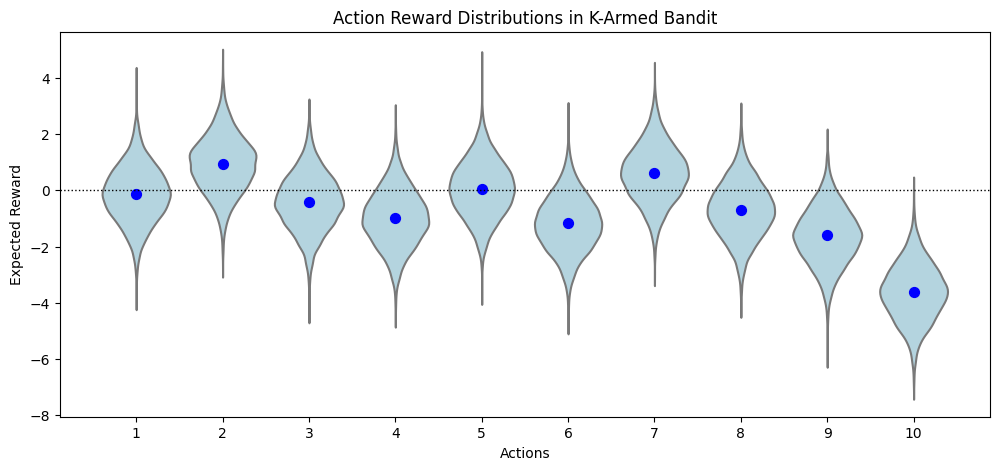

Saved GIF to: assets/bandit_training.gif


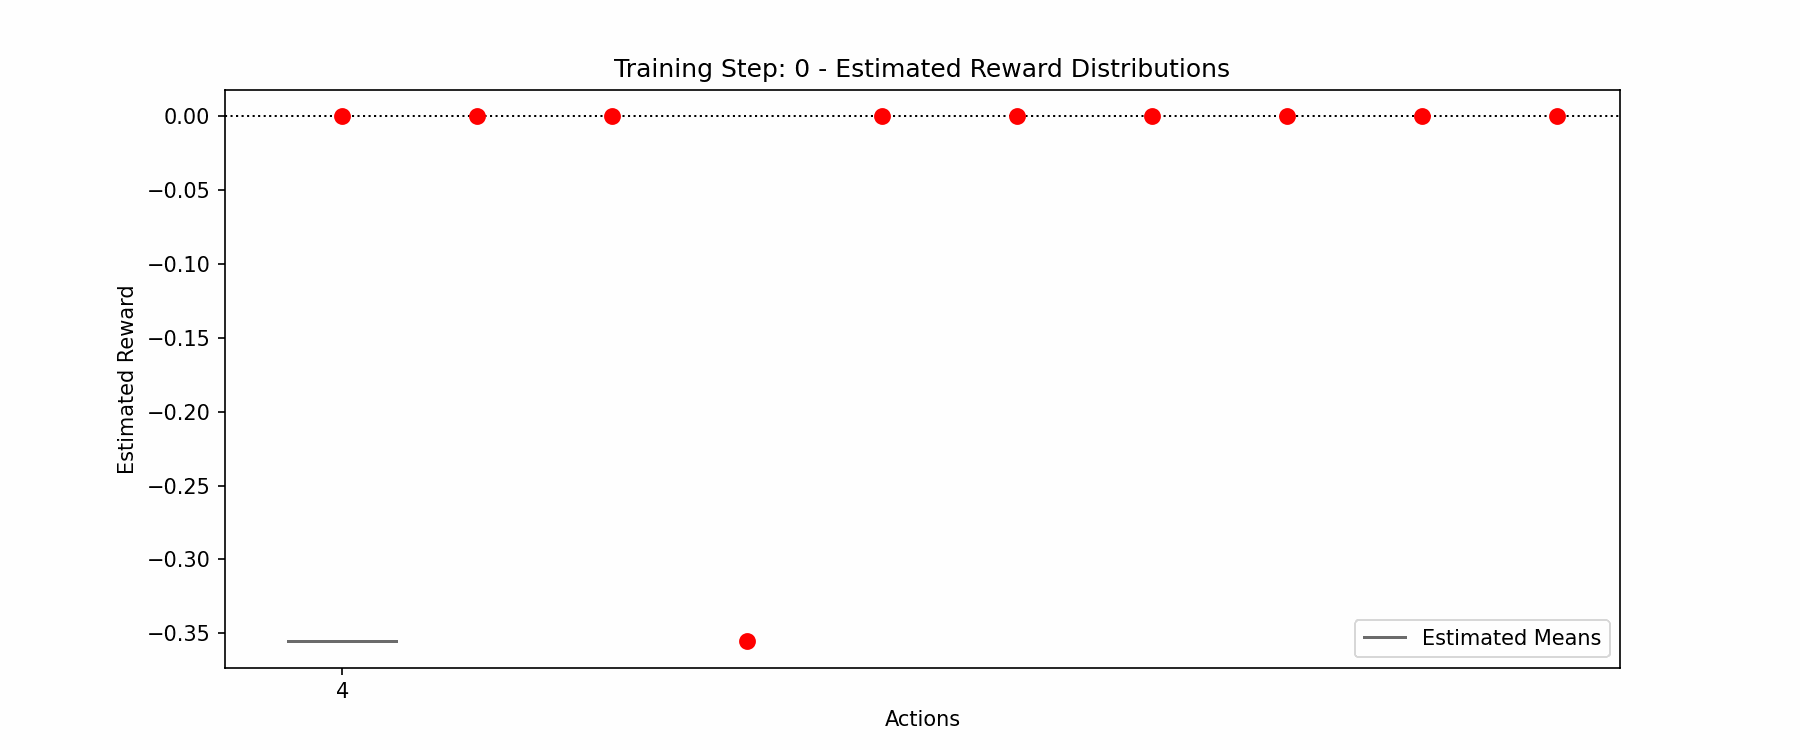

In [12]:
# Initialize bandit and strategy


K = 10  # Number of arms
bandit = KArmedBandit(K)
strategy = EpsilonGreedy(k=K, epsilon=0.2)

# Training loop with in-memory frame capture for GIF export
n_steps = 5000
plot_interval = n_steps // 50

# Plot initial bandit distributions before training
plot_bandit_distributions(bandit)

# Ensure the assets directory exists for saving frames and GIF
Path("assets").mkdir(parents=True, exist_ok=True)
tmp_frame = Path("assets/.tmp_bandit_frame.png")
frames = []

for step in range(n_steps + 1):
    action = strategy.act()
    reward = bandit.get_reward(action)
    strategy.update(action, reward)

    if step % plot_interval == 0:
        plot_and_save(strategy, step, save_path=str(tmp_frame))
        frames.append(Image.open(tmp_frame).copy())

# Build GIF from captured frames (for website use)
gif_path = Path("assets/bandit_training.gif")
if frames:
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=120,
        loop=0,
    )

for fr in frames:
    fr.close()

tmp_frame.unlink(missing_ok=True)

print(f"Saved GIF to: {gif_path}")
display(IPyImage(filename=str(gif_path)))


Test of $\varepsilon$-greedy Action Selection.

### Epsilon sensitivity

Compare greedy (`epsilon=0`) and exploratory (`epsilon>0`) behavior.

What to check while reading the plots:
- short-term reward vs long-term reward,
- how quickly each method discovers good arms,
- whether pure greedy gets stuck because it under-explores.

This directly matches the exploration-exploitation discussion in Section 2.1–2.2 {cite}`sutton2018`.


Simulating Greedy:   0%|          | 0/2000 [00:00<?, ?it/s]

Simulating $\varepsilon$-greedy, $\varepsilon = 0.1$:   0%|          | 0/2000 [00:00<?, ?it/s]

Simulating $\varepsilon$-greedy, $\varepsilon = 0.01$:   0%|          | 0/2000 [00:00<?, ?it/s]

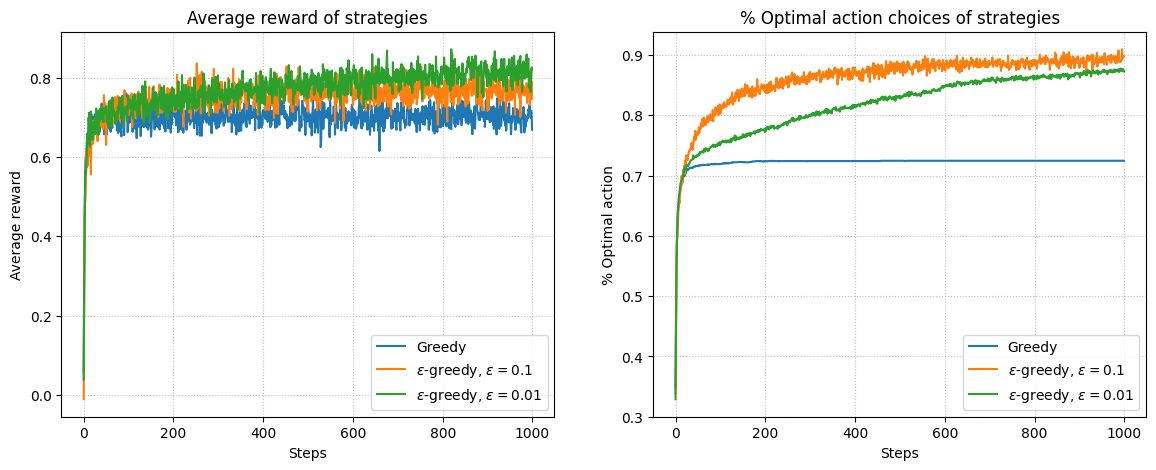

In [13]:
K = 3  # Number of actions

# List of strategies to test
strategies = [EpsilonGreedy(K,epsilon=0.0),
              EpsilonGreedy(K, epsilon=0.1),
              EpsilonGreedy(K, epsilon=0.01)]

# Evaluate strategies
rewards, best_action_choices = simulate(strategies, K=K, runs=2000, n_steps=1000)

plotResults(strategies, rewards, best_action_choices)

### Optimistic initialization and step-size

Here the initial action-value estimates are intentionally high (`initial > 0`), which induces early exploration even with small `epsilon`.

Also note the role of `step_size`:
- sample-average update (`1/N`) gives long memory,
- constant step-size gives faster adaptation.

See the action-value update discussion in Chapter 2 {cite}`sutton2018`.


Simulating Greedy, init: 10:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating $\varepsilon$-greedy, $\varepsilon = 0.1$, init: 3:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating $\varepsilon$-greedy, $\varepsilon = 0.1$:   0%|          | 0/200 [00:00<?, ?it/s]

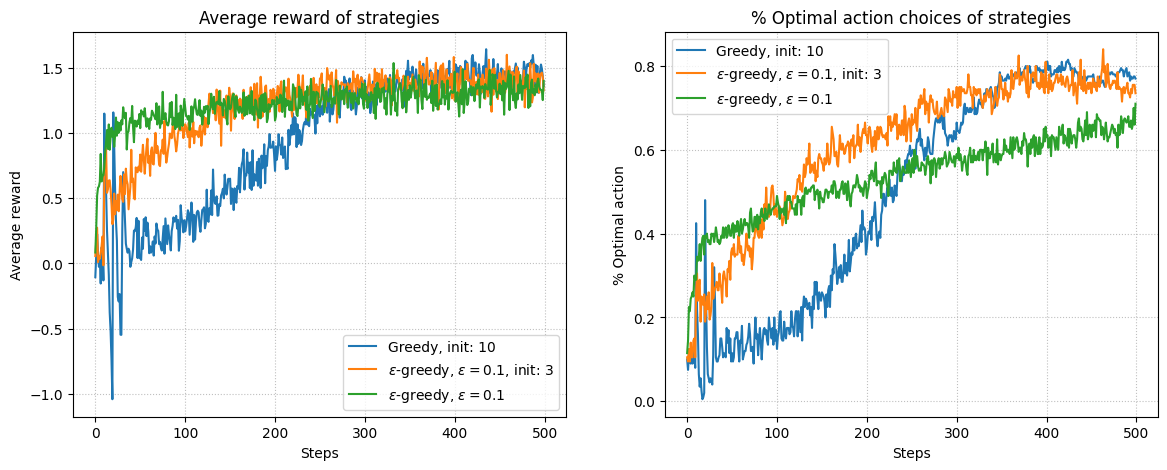

In [14]:
K = 10  # Number of actions

# List of strategies to test
strategies = [EpsilonGreedy(K,epsilon=0.0, initial=10,step_size=0.1),
              EpsilonGreedy(K, epsilon=0.1,initial=3,step_size=0.1),
              EpsilonGreedy(K, epsilon=0.1, initial=0,step_size=0.1)]

# Evaluate strategies
rewards, best_action_choices = simulate(strategies, K=K, runs=200, n_steps=500)

plotResults(strategies, rewards, best_action_choices)

## Upper-Confidence-Bound (UCB) Action Selection

The UCB action selection method offers a way to select an action by taking both the estimated value, as well as the accuracy of those estimates into account.
It uses the following formula:

$$ A_t := \underset{a}{\arg\max} \left[ Q_t(a) + c \sqrt{\frac{\ln(t)}{N_t(a)}} \right] $$

Where $Q_t(a)$ denotes the value of action $a$ (calculated using the *sample-averages* method), $N_t(a)$ denotes the number of times that action $a$ has
been selected prior to time $t$, and the number $c > 0$ controls
the degree of exploration. If $N_t(a) = 0$, then $a$ is considered to be a maximizing action.




### Task 4

**Implement UCB Strategy** (15 min)

Complete the `UCB` class using the Upper Confidence Bound action-selection rule.

Implement the following methods:

- `__init__(self, k, c=1, initial=0, step_size=None)`
  - store the UCB hyperparameters (`c`, `initial`, optional `step_size`)
  - initialize action-value estimates for all actions
  - initialize action selection counts
  - initialize the time-step counter `t`

- `act(self)`
  - if there are actions that have not been selected yet, choose among them
  - otherwise compute UCB score for each action:
    $$
    Q(a) + c \sqrt{\frac{\log(t+1)}{N(a)}}
    $$
  - return the action with the highest UCB score (use random tie-breaking)

- `update(self, action, reward)`
  - increment the global time step counter
  - increment the selection count of the chosen action
  - update the chosen action-value estimate
  - support both update modes:
    - sample-average update when `step_size is None`
    - constant step-size update when `step_size` is provided

- `reset(self)`
  - reset time step counter, action-value estimates, and action counts to initial state


In [15]:
import numpy as np

class UCB(Strategy):
    """
    Implements the Upper Confidence Bound (UCB) action selection strategy.
    This method balances exploration and exploitation by selecting actions
    with the highest estimated value plus an uncertainty bonus.
    """

    def __init__(self, k, c=1, initial=0, step_size=None):
        """
        Initializes the UCB strategy.

        Parameters:
        - k (int): Number of actions (arms).
        - c (float): Exploration degree (higher c encourages more exploration).
        - initial (float): Initial estimate for action values.
        """
        super().__init__(k)  # Initialize parent Strategy class
        self.c = c
        self.initial = initial
        self.step_size = step_size
        self.q_estimations = np.full(self.k, self.initial, dtype=float)
        self.action_counts = np.zeros(self.k, dtype=int)
        self.t = 0

    @property
    def name(self):
        """
        Returns a formatted string representing the UCB strategy name.
        """
        return f"UCB, $c = {self.c}$"

    def act(self):
        """
        Selects an action using the UCB formula.

        Returns:
        - (int) Index of the selected action.
        """
        # Calculate the UCB upper confidence bound for each action:
        # UCB = Q(a) + c * sqrt( log(t) / N(a) )
        # - Q(a): Estimated value of action a
        # - c: Degree of exploration (hyperparameter)
        # - t: Current time step
        # - N(a): Number of times action a has been selected

        # Ensure each action is selected at least once before applying UCB bonus
        unexplored = np.where(self.action_counts == 0)[0]
        if len(unexplored) > 0:
            return np.random.choice(unexplored)
        ucb_values = self.q_estimations + self.c * np.sqrt(np.log(self.t) / self.action_counts)
        return argmax(ucb_values)

    def update(self, action, reward):
        """
        Updates action value estimates using sample averaging.

        Parameters:
        - action (int): Index of the chosen action.
        - reward (float): Reward received from the environment.
        """
        super().update(action, reward)
        self.t += 1
        self.action_counts[action] += 1
        alpha = 1.0 / self.action_counts[action] if self.step_size is None else self.step_size
        self.q_estimations[action] += alpha * (reward - self.q_estimations[action])

    def reset(self):
        """
        Resets the internal state of the UCB strategy for a new experiment.
        """
        super().reset()
        self.q_estimations = np.full(self.k, self.initial, dtype=float)
        self.action_counts = np.zeros(self.k, dtype=int)
        self.t = 0


### UCB exploration coefficient

UCB uses an explicit uncertainty bonus, controlled by `c`.

Interpretation goal:
- small `c`: more exploitation,
- large `c`: more exploration pressure.

This is the confidence-bound approach from Section 2.7 {cite}`sutton2018`.


Simulating UCB, $c = 1$:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating UCB, $c = 2$:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating UCB, $c = 5$:   0%|          | 0/200 [00:00<?, ?it/s]

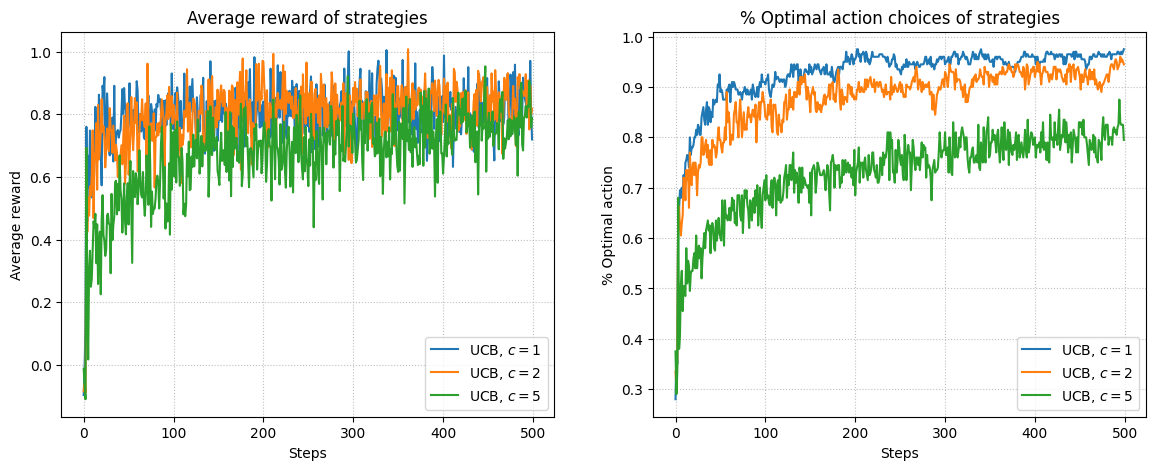

In [16]:
K = 3  # Number of actions

# List of strategies to test
strategies = [UCB(K),
              UCB(K, c=2),
              UCB(K, c=5)]

# Evaluate strategies
rewards, best_action_choices = simulate(strategies, K=K, runs=200, n_steps=500)

plotResults(strategies, rewards, best_action_choices)

## Gradient Bandit Algorithms

Instead of estimating action values, this method learns a numerical *preference*, denoted $H_t(a)$ for each action. The larger the preference, the more often that action is taken, but the preference has no interpretation in terms of reward. Action probabilites are determined using the *soft-max* function:

$$ \pi_t(a) := \Pr\{A_t = a\} := \frac{e^{H_t(a)}}{\sum_{b=1}^k e^{H_t(b)}} $$

Here we have also introduced a useful new notation, $\pi_t(a)$, for the probability of
taking action $a$ at time $t$. Note that this function defines a probability distribution over the set of all actions. On each step, after selecting action $A_t$ and receiving the reward $R_t$, the
action preferences are updated by:

$$ H_{t+1}(a) := H_t(a) + \alpha(R_t - \bar{R}_t)(\mathbb{1}_{a=A_t} - \pi_t(a)) $$

Where $\alpha > 0$ is a step-size parameter, and $\bar{R}_t \in \mathbb{R}$ is the average of all the rewards up
through and including time $t$.
The $\bar{R}_t$ term serves as a
baseline with which the reward is compared.



### Task 5

**Implement Gradient Bandit Strategy** (15 min)

Complete the `Gradient` class using preference-based policy optimization.

Implement the following methods:

- `__init__(self, k, step_size=0.1, use_baseline=True)`
  - store learning rate (`alpha`) and baseline flag
  - initialize action preferences $ H(a) $
  - initialize baseline reward estimate
  - initialize time-step counter `t`
  - prepare action index list for sampling

- `act(self)`
  - convert current preferences to action probabilities with softmax
  - sample an action according to this probability distribution

- `update(self, action, reward)`
  - increment time step counter
  - if baseline is enabled, update baseline reward estimate incrementally
  - build a one-hot vector for the selected action
  - update all preferences with the gradient bandit rule:
    $$
    H(a) \leftarrow H(a) + \alpha (R - \text{baseline}) (I(a) - \pi(a))
    $$
  - where $ \pi(a) $ is the softmax policy and $ I(a) $ is the one-hot indicator

- `reset(self)`
  - reset preferences, baseline, and time-step counter

- `softmax(self, x)`
  - implement numerically stable softmax for preference-to-probability conversion

In [17]:
import numpy as np

class Gradient(Strategy):
    """
    Implements the Gradient Bandit Algorithm.
    This method uses policy gradient updates to optimize action selection.
    """

    def __init__(self, k,step_size=0.1, use_baseline = True):
        """
        Initializes the Gradient Bandit strategy.

        Parameters:
        - k (int): Number of actions (arms).
        - alpha (float): Step-size parameter for updating action preferences.
        """
        super().__init__(k)  # Initialize parent Strategy class
        self.alpha = step_size
        self.use_baseline = use_baseline
        self.preferences = np.zeros(self.k, dtype=float)
        self.baseline = 0.0
        self.t = 0
        self.action_indices = np.arange(self.k)

    @property
    def name(self):
        """
        Returns a formatted string representing the strategy name.
        """
        return f"Gradient, $\\alpha = {self.alpha}$" if self.use_baseline else f"Gradient, $\\alpha = {self.alpha}$, No Baseline"

    def act(self):
        """
        Selects an action based on the softmax probabilities.

        Returns:
        - (int) Index of the selected action.
        """
        probs = self.softmax(self.preferences)
        return np.random.choice(self.action_indices, p=probs)

    def update(self, action, reward):
        """
        Updates action preferences using policy gradient.

        Parameters:
        - action (int): Index of the chosen action.
        - reward (float): Reward received from the environment.
        """
        super().update(action, reward)  # Call parent class update method if needed
        self.t += 1
        if self.use_baseline:
            self.baseline += (reward - self.baseline) / self.t
        baseline_val = self.baseline if self.use_baseline else 0.0
        probs = self.softmax(self.preferences)
        one_hot = np.zeros(self.k)
        one_hot[action] = 1.0
        self.preferences += self.alpha * (reward - baseline_val) * (one_hot - probs)

    def reset(self):
        """
        Resets the internal state of the Gradient Bandit strategy.
        """
        super().reset()
        self.preferences = np.zeros(self.k, dtype=float)
        self.baseline = 0.0
        self.t = 0

    def softmax(self, x):
        """
        Computes the softmax probability distribution.

        Parameters:
        - x (np.array): Input preferences.

        Returns:
        - (np.array): Probability distribution over actions.
        """
        exp_x = np.exp(x - np.max(x))
        return exp_x / np.sum(exp_x)


Test of Gradient Bandit Algorithm.

### Gradient bandit hyperparameters

Gradient bandits optimize action preferences via a softmax policy.

Focus points:
- effect of $ \alpha $ (step-size) on stability/speed,
- effect of using a baseline (variance reduction).

This corresponds to Section 2.8 (gradient bandit algorithm) {cite}`sutton2018`.


Simulating Gradient, $\alpha = 0.1$:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating Gradient, $\alpha = 0.4$:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating Gradient, $\alpha = 0.01$:   0%|          | 0/200 [00:00<?, ?it/s]

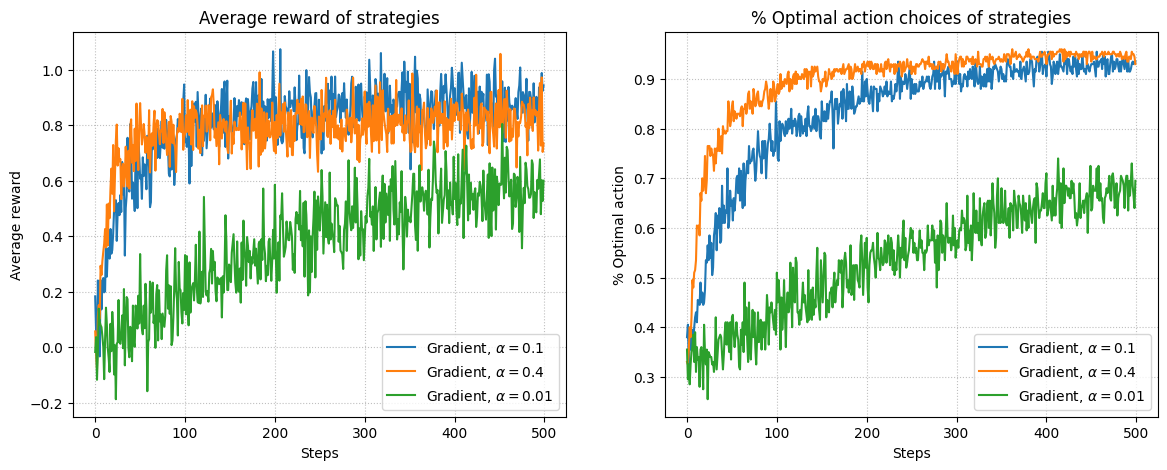

In [18]:
K = 3  # Number of actions

# List of strategies to test
strategies = [Gradient(K,step_size=0.1),
              Gradient(K, step_size=0.4),
              Gradient(K, step_size=0.01)]

# Evaluate strategies
rewards, best_action_choices = simulate(strategies, K=K, runs=200, n_steps=500)

plotResults(strategies, rewards, best_action_choices)

Simulating Gradient, $\alpha = 0.1$:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating Gradient, $\alpha = 0.1$, No Baseline:   0%|          | 0/200 [00:00<?, ?it/s]

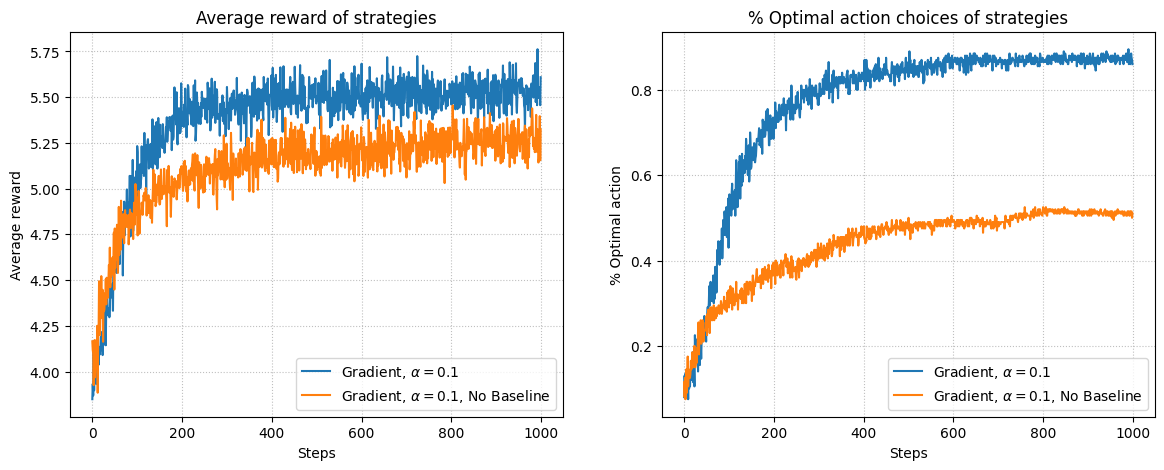

In [19]:
K = 10  # Number of actions

# List of strategies to test
strategies = [Gradient(K,step_size=0.1),
             #Gradient(K, step_size=0.4),
              Gradient(K, step_size=0.1, use_baseline=False),
             #Gradient(K, step_size=0.4, use_baseline=False)
             ]

# Evaluate strategies
rewards, best_action_choices = simulate(strategies, K=K,bandit_mean=4, runs=200, n_steps=1000)

plotResults(strategies, rewards, best_action_choices)

## Comprehensive test

In this final section let's run a longer comprehensive test with more actions.

The comparison setup is aligned with the classical ten-armed testbed style in {cite}`zhang_ten_armed`.


Simulating Greedy:   0%|          | 0/2000 [00:00<?, ?it/s]

Simulating $\varepsilon$-greedy, $\varepsilon = 0.1$:   0%|          | 0/2000 [00:00<?, ?it/s]

Simulating UCB, $c = 2$:   0%|          | 0/2000 [00:00<?, ?it/s]

Simulating Gradient, $\alpha = 0.1$:   0%|          | 0/2000 [00:00<?, ?it/s]

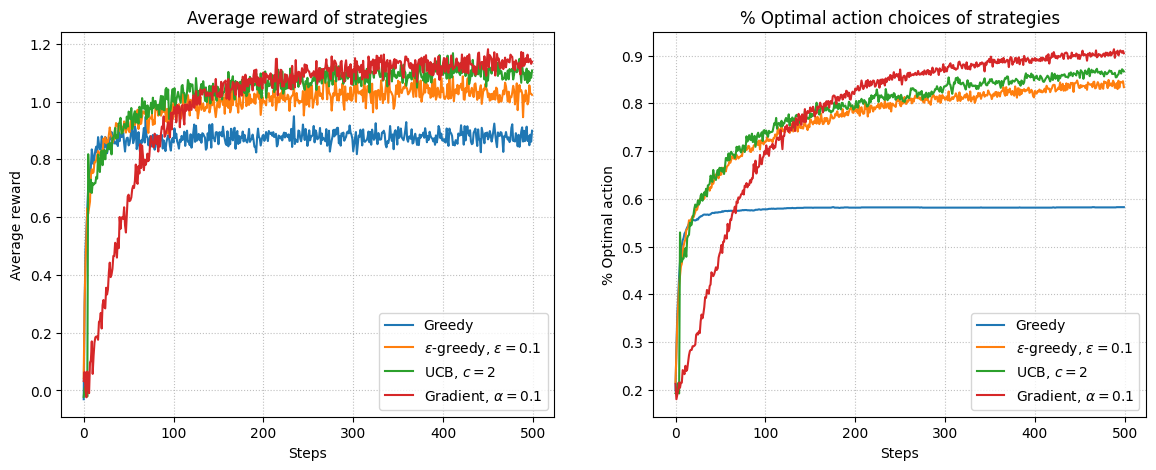

In [21]:
K = 5  # Number of actions

# List of strategies to test
strategies = [
        EpsilonGreedy(K),
        EpsilonGreedy(K, epsilon=0.1),
        UCB(K, c=2),
        Gradient(K)
    ]

# Evaluate strategies
rewards, best_action_choices = simulate(strategies, K=K, runs=2000, n_steps=500)

plotResults(strategies, rewards, best_action_choices)

## Non-stationary bandits and constant learning rate

So far we used stationary bandits, where each arm has a fixed true value.
In a **non-stationary** setting, the true action values drift over time.

In this case, sample-average updates (step-size $ 1/N $) can react too slowly, because they keep very long memory.
A constant step-size $ \alpha $ tracks recent changes better, as discussed in Sutton & Barto {cite}`sutton2018`.

Below we compare:
- $ \varepsilon $-greedy with sample-average updates,
- $ \varepsilon $-greedy with constant step-size updates.


### Why non-stationarity changes the conclusion

When true action values drift, old data becomes less reliable.

Key takeaway to verify in plots:
- sample-average update can lag behind changing optima,
- constant `alpha` tracks drift better because it weights recent rewards more.

This is the main motivation behind constant step-size updates in non-stationary bandits (Section 2.5) {cite}`sutton2018`.


### Task 6

**Implement Non-Stationary Bandit and Evaluation** (20-25 min)

In this task, extend the environment and evaluation to the non-stationary setting.

Implement the following components:

- `NonStationaryKArmedBandit`
  - `__init__(self, K, mean=0.0, std_dev=1.0, drift_std=0.01, reward_std=1.0)`
    - initialize number of actions and noise parameters
    - sample initial true action values
    - store current best action index
  - `step_dynamics(self)`
    - apply random-walk drift to all true action values
    - update current best action index
  - `get_reward(self, action)`
    - sample reward around current true value of selected action
  - `get_optimal_action(self)`
    - return current best action index

- `simulate_nonstationary(strategies, K, runs=200, n_steps=2000, drift_std=0.01, reward_std=1.0)`
  - evaluate each strategy across independent runs
  - for each run:
    - create a fresh non-stationary bandit
    - reset strategy state
    - for each time step:
      - read current optimal action
      - select action, sample reward, update strategy
      - log reward and optimal-action hit
      - apply environment drift via `step_dynamics()`
  - return run-averaged:
    - mean reward curves
    - optimal-action selection-rate curves

- `EpsilonGreedyWithLabel(EpsilonGreedy)`
  - add a readable `name` property variant that indicates update mode
  - distinguish sample-average vs constant step-size settings in labels

Use these components to compare epsilon-greedy variants under drift by running `simulate_nonstationary(...)` and plotting with `plotResults(...)`.

In [22]:
class NonStationaryKArmedBandit:
    def __init__(self, K, mean=0.0, std_dev=1.0, drift_std=0.01, reward_std=1.0):
        self.K = K
        self.mean = mean
        self.std_dev = std_dev
        self.drift_std = drift_std
        self.reward_std = reward_std
        self.actions_means = np.random.normal(self.mean, self.std_dev, self.K)
        self.best_action = np.argmax(self.actions_means)

    def step_dynamics(self):
        # Apply a random-walk drift to action values over time
        self.actions_means += np.random.normal(0, self.drift_std, self.K)
        self.best_action = np.argmax(self.actions_means)

    def get_reward(self, action):
        return np.random.normal(self.actions_means[action], self.reward_std)

    def get_optimal_action(self):
        return self.best_action


def simulate_nonstationary(strategies, K, runs=200, n_steps=2000, drift_std=0.01, reward_std=1.0):
    rewards = np.zeros((len(strategies), runs, n_steps))
    best_action_choices = np.zeros_like(rewards)

    for i, strategy in enumerate(strategies):
        for run in trange(runs, desc=f"Simulating {strategy.name} (Drift)", leave=False):
            bandit = NonStationaryKArmedBandit(
                K, drift_std=drift_std, reward_std=reward_std
            )
            strategy.reset()

            for t in range(n_steps):
                optimal_action = bandit.get_optimal_action()

                action = strategy.act()
                reward = bandit.get_reward(action)
                strategy.update(action, reward)

                rewards[i, run, t] = reward
                best_action_choices[i, run, t] = 1 if action == optimal_action else 0

                # Apply environment drift after each step
                bandit.step_dynamics()

    mean_rewards = rewards.mean(axis=1)
    mean_best_action_choices = best_action_choices.mean(axis=1)
    return mean_rewards, mean_best_action_choices


Simulating $\varepsilon$-greedy, $\varepsilon = 0.1$, Sample Average (Drift):   0%|          | 0/200 [00:00<?,…

Simulating $\varepsilon$-greedy, $\varepsilon = 0.1$, Constant Step Size 0.1 (Drift):   0%|          | 0/200 […

Simulating $\varepsilon$-greedy, $\varepsilon = 0.1$, Constant Step Size 0.01 (Drift):   0%|          | 0/200 …

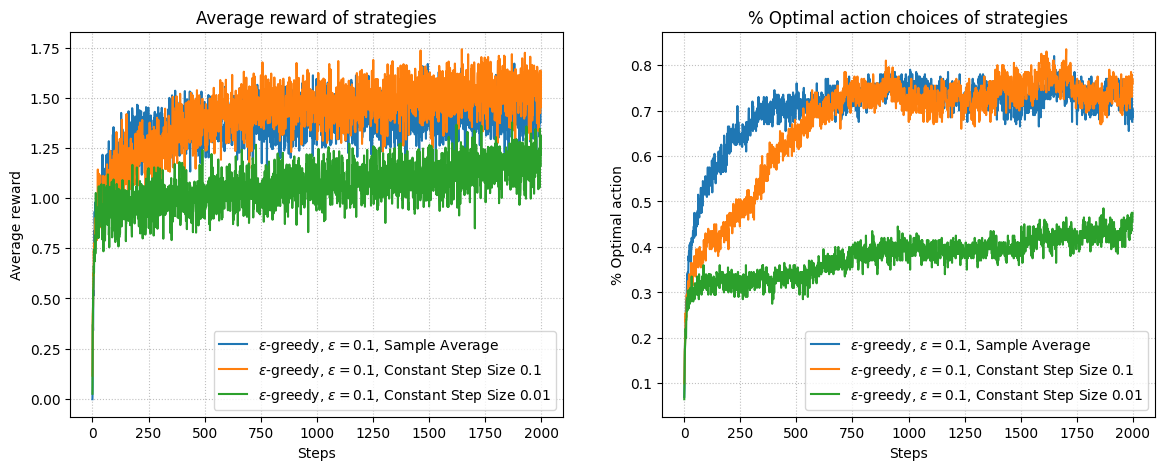

In [23]:

K = 10
strategies_nonstationary = [
    EpsilonGreedy(K, epsilon=0.1, step_size=None,name_suffix="Sample Average"),
    EpsilonGreedy(K, epsilon=0.1, step_size=0.1,name_suffix="Constant Step Size 0.1"),
    EpsilonGreedy(K, epsilon=0.1, step_size=0.01,name_suffix="Constant Step Size 0.01"),
]

rewards_ns, best_action_choices_ns = simulate_nonstationary(
    strategies_nonstationary,
    K=K,
    runs=200,
    n_steps=2000,
    drift_std=0.01,
)

plotResults(strategies_nonstationary, rewards_ns, best_action_choices_ns)